(mmm_experiment_designer)=
# Experiment Designer: Posterior-Aware Lift Test Design

:::{warning}
This is **experimental functionality**. The current implementation works at the national level but does not yet support geo-level experiment design. We are very interested in hearing from users — would this be useful in your workflow? What directions should we prioritise? Please open an issue or start a discussion on the [PyMC-Marketing GitHub](https://github.com/pymc-labs/pymc-marketing) with your feedback.
:::

You've fitted a Marketing Mix Model — now what? You know you should run a lift test to validate the model, but you face a set of awkward design questions:

- **Which channel** should you test?
- **At what spend level** — where on the saturation curve should the test probe?
- **For how long** — what duration balances statistical power against cost?
- **What is the expected lift**, given all the uncertainty in the model?

Traditional experiment design tools (e.g. GeoLift) require the practitioner to *guess* the expected effect size up front — the very quantity the experiment is supposed to measure. This creates a chicken-and-egg problem.

The `ExperimentDesigner` sidesteps this by using the fitted MMM's posterior distribution directly. The posterior already encodes what the model believes about each channel's response function, including its uncertainty. For every candidate experiment (channel × spend change × duration), the designer pushes each posterior draw through the adstock and saturation transforms to produce a **distribution of predicted lifts** — not a single point estimate. From that distribution it computes **Bayesian assurance** (posterior-predictive power) and ranks candidates by a composite score that balances informativeness, detectability, and cost.

:::{tip}
If you want to jump straight to the code, skip ahead to the [Workflow](#workflow) section.
:::

In [1]:
import matplotlib.pyplot as plt

from pymc_marketing.mmm.experiment_design import (
    ExperimentDesigner,
    generate_experiment_fixture,
)

%config InlineBackend.figure_format = "retina"

FIG_WIDTH = 10
FIG_HEIGHT = 4

CHANNEL_COLORS = {"tv": "C0", "search": "C1", "social": "C2"}

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/benjamv/mambaforge/envs/pymc-marketing-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## How It Works

This section explains the key ideas behind the `ExperimentDesigner`. Understanding these concepts will make the workflow outputs much easier to interpret.

### The Core Insight: Using the Posterior Instead of Guessing

Standard power analysis requires a **minimum detectable effect (MDE)** — the analyst must specify the effect size they expect the experiment to find. But if you already knew the effect size, you wouldn't need the experiment.

The `ExperimentDesigner` resolves this by using the fitted MMM's posterior. Each posterior draw defines a complete channel response function (adstock decay $\alpha$, saturation half-life $\lambda$, channel scale $\beta$). For a given spend change, every draw implies a different predicted lift. The result is a **posterior distribution of predicted lifts** rather than a single number.

This means the designer doesn't need you to guess anything — it inherits the model's beliefs *and* uncertainties about each channel. Channels the model is confident about will yield tight lift distributions; channels with wide posteriors will produce spread-out lift distributions that honestly reflect the risk that the true effect might be small.

### Adstock-Aware Lift Prediction

A spend change doesn't produce its full effect overnight. In an MMM with geometric adstock, the *effective* (adstocked) spend ramps up over several weeks before reaching steady state. The designer models this ramp explicitly so that predicted lifts are realistic for short experiments.

The lift prediction pipeline works as follows:

1. **Steady-state adstocked spend.** Given current weekly spend $x$ and adstock decay $\alpha$ with maximum lag $L$, the steady-state adstocked spend is

$$x_{\text{ss}} = x \cdot \frac{1 - \alpha^{L}}{1 - \alpha}$$

   (For normalised adstock where the weights sum to 1, $x_{\text{ss}} = x$.)

2. **Adstock ramp.** When spend changes at week $t = 0$, the adstocked spend doesn't jump to the new steady state immediately. At week $t$ the partial geometric sum is

$$r_t = \frac{1 - \alpha^{t+1}}{1 - \alpha}$$

   The **ramp fraction** $r_t / S$ tells us what share of the steady-state effect has been reached by week $t$. Channels with slow decay (high $\alpha$) ramp slowly and need longer experiments.

3. **Effective spend per week.** Combining the baseline and the ramped change:

$$x_{\text{eff},t} = x_{\text{ss}} + \Delta x \cdot r_t$$

   where $\Delta x$ is the absolute spend change.

4. **Weekly lift through saturation.** Each week's lift is the difference between the response at the new effective spend and the baseline response:

$$\ell_t = f(x_{\text{eff},t}) - f(x_{\text{ss}})$$

   where $f$ is the logistic saturation function $f(x) = \beta\,(1 - e^{-\lambda x}) / (1 + e^{-\lambda x})$.

5. **Total lift.** The cumulative lift over a $T$-week experiment is $L = \sum_{t=0}^{T-1} \ell_t$. Because every quantity above depends on the posterior draw $(\lambda, \beta, \alpha)$, we obtain a full posterior distribution of $L$.

### Bayesian Assurance (Posterior-Predictive Power)

With a posterior distribution of predicted lifts in hand, the next question is: *if the true effect is drawn from this posterior, how likely is the experiment to detect it?*

Traditional power analysis answers this for a single assumed effect size $\theta_0$:

$$\text{Power}(\theta_0) = P\!\bigl(\text{reject } H_0 \mid \theta = \theta_0\bigr)$$

**Bayesian assurance** averages power over the entire posterior, weighting each possible effect size by how plausible the model considers it:

$$\text{Assurance} = \mathbb{E}_{\theta \sim \text{posterior}}\!\left[\text{Power}(\theta)\right]$$

In practice, this is computed per posterior draw. For each draw $i$:

1. Compute the predicted cumulative lift $L_i$.
2. Derive the non-centrality parameter: $\text{ncp}_i = |L_i| \,/\, \sigma_d$, where $\sigma_d = \sigma_\varepsilon \sqrt{T}$ is the cumulative measurement noise over $T$ weeks.
3. Evaluate two-sided power via the normal CDF.

The assurance is then the mean of per-draw power values across all posterior draws.

This produces natural behaviour:
- **Well-identified channels** with large posterior effects yield high assurance.
- **Uncertain channels** produce a spread of power values — the assurance honestly reflects the risk that the true effect may be too small to detect.
- **Posterior mass near zero** pulls assurance down, correctly signalling that the experiment may fail.

### Scoring and Ranking

Not every high-assurance experiment is worth running. A go-dark test on your largest channel might have excellent power but enormous opportunity cost. The designer ranks candidates by a **weighted composite score** across five normalised dimensions:

| Dimension | Default weight | What it captures |
|-----------|---------------|------------------|
| **Posterior uncertainty** | 0.20 | Channels with wide posteriors — where we'd learn the most |
| **Spend correlation** | 0.10 | Channels contributing to the identification problem (correlated spend makes it hard to attribute effects) |
| **Saturation gradient** | 0.10 | Channels where a spend change produces a large response change (steep part of the curve) |
| **Assurance** | 0.30 | Experiments likely to produce a statistically detectable signal |
| **Cost efficiency** | 0.30 | Assurance per unit of spend disruption — favouring cheaper experiments |

Each dimension is min-max normalised to $[0, 1]$ across all candidates, then combined via a weighted sum. Candidates are sorted by score in descending order.

Before scoring, a **signal-to-noise ratio (SNR) pre-filter** removes candidates whose expected lift is too small relative to measurement noise. This avoids wasting ranking capacity on experiments that have little chance of succeeding regardless of other factors.

The weights are configurable via the `score_weights` parameter, so teams can shift the balance toward informativeness, detectability, or cost depending on their priorities.

(workflow)=
## Workflow

With the concepts established, we now walk through the full workflow using a synthetic fixture with three channels.

### Step 1: Load a Fixture (or Use a Fitted MMM)

The `ExperimentDesigner` can be created from:
- A **fitted MMM** via `ExperimentDesigner(mmm)` — the primary workflow
- A **saved InferenceData** via `ExperimentDesigner.from_idata(idata)` — for demos and testing

Here we generate a synthetic fixture with known ground-truth parameters for three channels:

| Channel | λ (saturation efficiency) | β (scale) | α (adstock decay) |
|---------|--------------------------|-----------|--------------------|
| TV      | 0.5 (slow saturation)     | 3.0       | 0.7 (slow decay)   |
| Search  | 2.0 (fast saturation)     | 1.5       | 0.3 (fast decay)   |
| Social  | 1.0 (moderate)            | 0.8       | 0.5 (moderate)     |

In [2]:
idata = generate_experiment_fixture(
    channels=["tv", "search", "social"],
    true_params={
        "tv": {"lam": 0.5, "beta": 3.0, "alpha": 0.7},
        "search": {"lam": 2.0, "beta": 1.5, "alpha": 0.3},
        "social": {"lam": 1.0, "beta": 0.8, "alpha": 0.5},
    },
    fit_model=False,
    seed=42,
)

designer = ExperimentDesigner.from_idata(idata)
print(f"Channels: {designer.channel_columns}")
print(f"Posterior draws: {designer.n_draws}")
print(f"Adstock l_max: {designer.l_max}, normalize: {designer.normalize}")

Channels: [np.str_('tv'), np.str_('search'), np.str_('social')]
Posterior draws: 4000
Adstock l_max: 8, normalize: True


### Step 2: Inspect Posterior Uncertainty

Before recommending experiments, we visualise what the model believes about each channel. Channels with wide posteriors or high spend correlation are the ones where an experiment would be most informative.

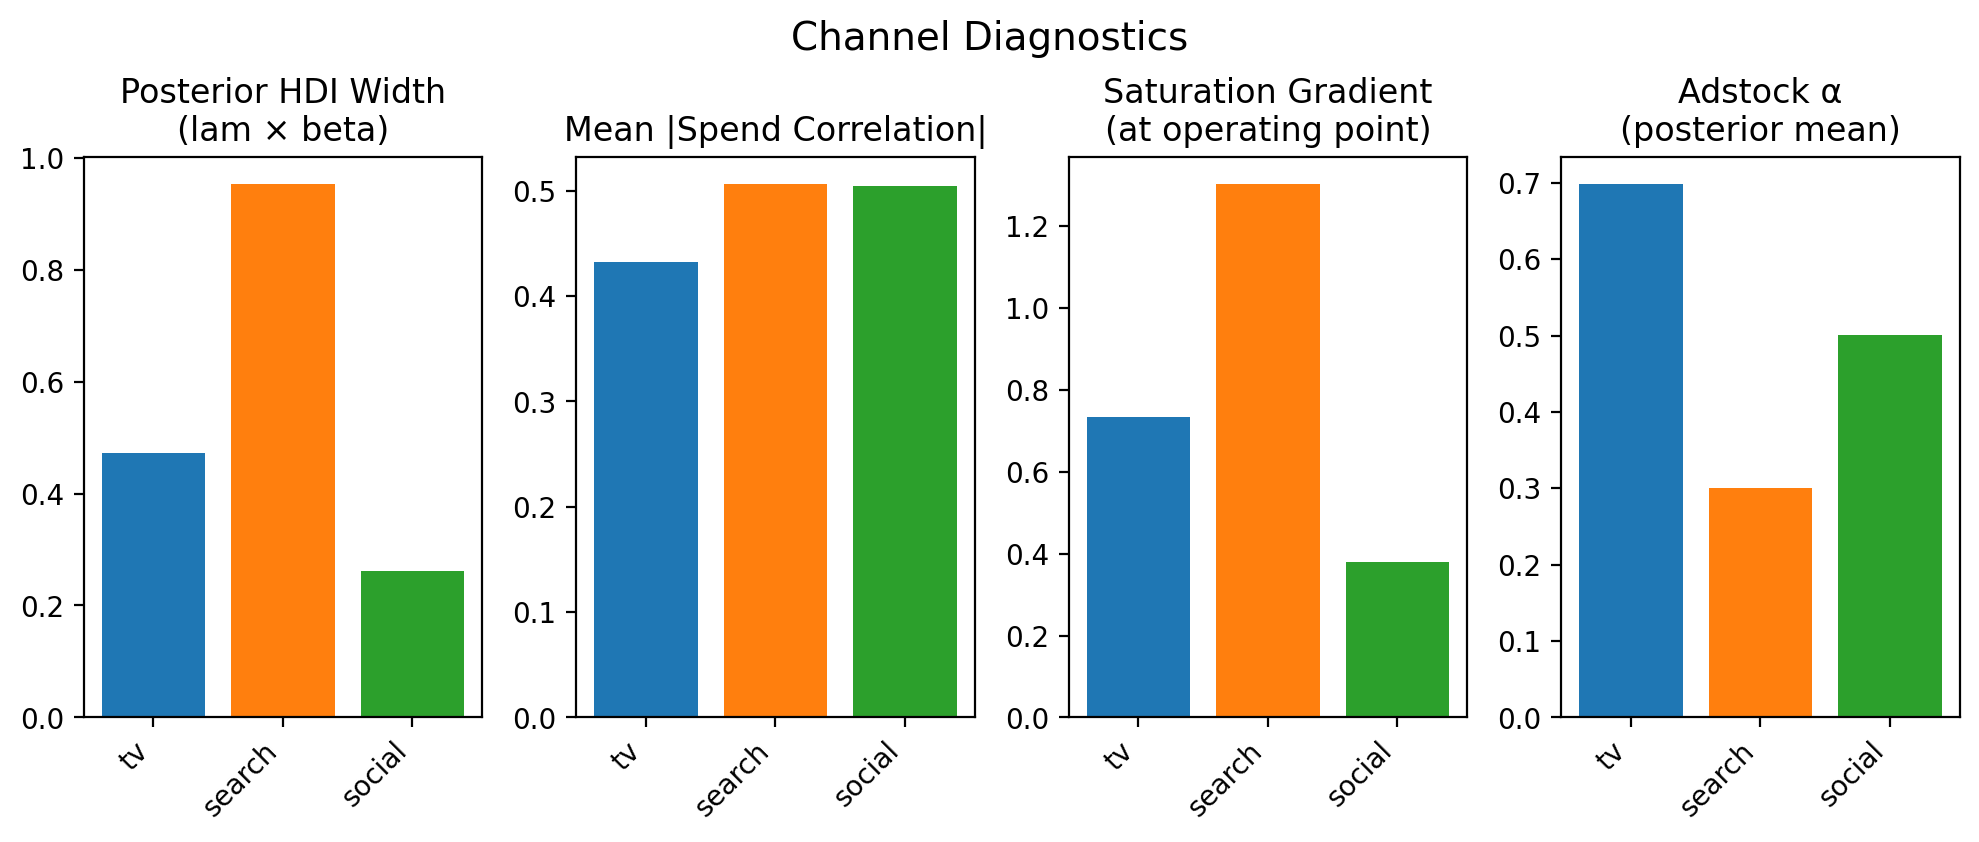

In [3]:
fig, axes = designer.plot_channel_diagnostics(
    colors=CHANNEL_COLORS, figsize=(FIG_WIDTH, FIG_HEIGHT)
)
fig.suptitle("Channel Diagnostics", fontsize=14, y=1.04)
plt.show()

**Caption:** Per-channel scoring dimensions used to rank experiment candidates: posterior HDI area (λ × β), mean absolute spend correlation, saturation gradient at the current operating point, and posterior mean adstock decay (α). Bars are color-coded by channel.

### Step 3: Visualise Saturation Curves

The saturation curve reveals where each channel sits on its diminishing-returns curve and how uncertain the model is about the shape. Channels whose HDI band is wide at the operating point are prime candidates for a lift test.

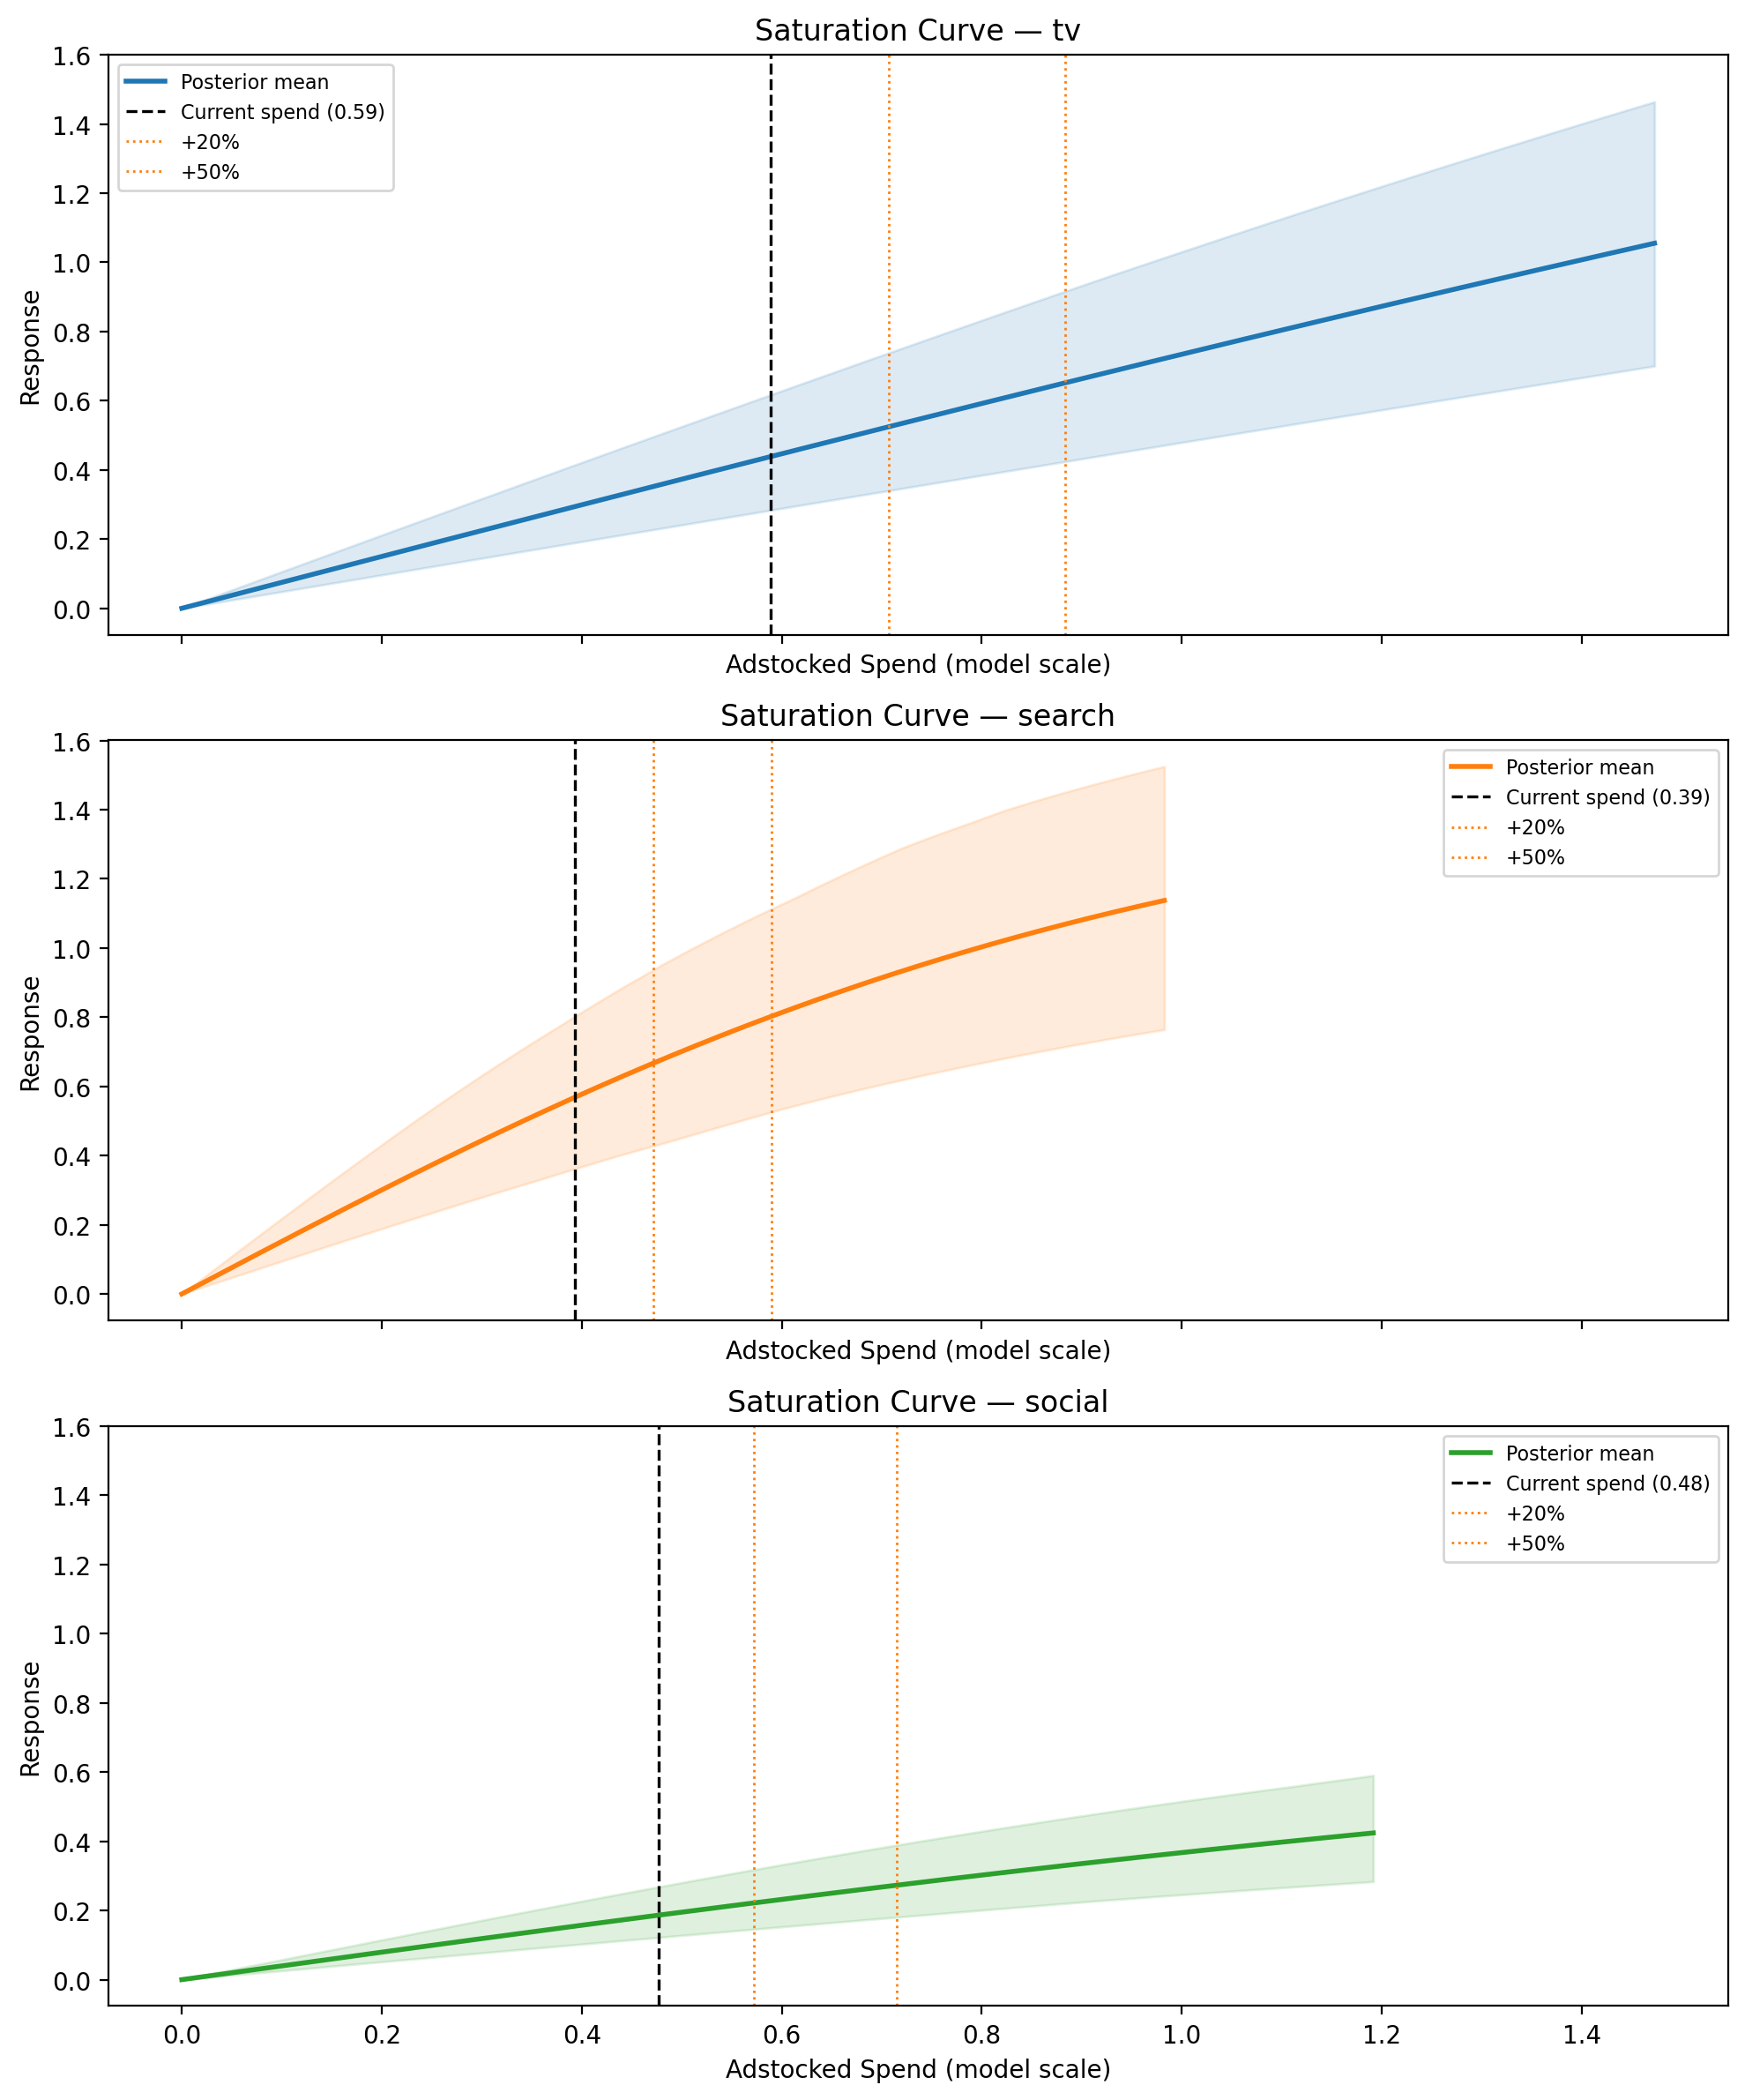

In [4]:
fig, axes = plt.subplots(
    3, 1, figsize=(FIG_WIDTH, FIG_HEIGHT * 3), sharex=True, sharey=True
)

for ax, channel in zip(axes, designer.channel_columns, strict=True):
    designer.plot_saturation_curve(
        channel, spend_levels=[0.2, 0.5], ax=ax, color=CHANNEL_COLORS[channel]
    )

fig.tight_layout()
plt.show()

**Caption:** Posterior saturation curves for each channel. Shaded band is the 94% HDI across all posterior draws; vertical dashed line marks current weekly spend; dotted lines mark candidate spend levels (+20%, +50%).

### Step 4: Recommend Experiments

The `recommend()` method evaluates a grid of candidate experiments across all channels and returns a ranked list. Each candidate is defined by a channel, a fractional spend change, and a duration in weeks. The designer computes predicted lift, assurance, adstock ramp fraction, net cost, and composite score for each candidate as described in [How It Works](#how-it-works) above.

In [5]:
import time

spend_changes = [0.1, 0.2, 0.3, 0.5, -0.2, -0.5, -1.0]
durations = [4, 6, 8, 12]
n_candidates = len(designer.channel_columns) * len(spend_changes) * len(durations)

t0 = time.perf_counter()
recommendations = designer.recommend(
    spend_changes=spend_changes,
    durations=durations,
    min_snr=2.0,
    significance_level=0.05,
)
elapsed = time.perf_counter() - t0

In [6]:
print(
    f"Evaluated {n_candidates} candidate experiments evaluated in {elapsed:.2f}s "
    f"({n_candidates / elapsed:.0f} candidates/sec) "
    f"— {len(recommendations)} passed min_snr filter"
)

Evaluated 84 candidate experiments evaluated in 2.15s (39 candidates/sec) — 77 passed min_snr filter


#### Recommendation Table

The returned `ExperimentRecommendations` object renders as an HTML table automatically in Jupyter. Slicing returns a new container:

In [7]:
recommendations[:10]

Rank,Channel,Δ Spend,Duration,E[Lift],Lift 94% HDI,SNR,Assurance,Ramp,Score
1,search,-20%/wk,4w,-0.4,"[-1, -0]",-5.5,0.99,0.89,0.896
2,search,+20%/wk,4w,0.4,"[0, 0]",5.2,0.99,0.89,0.894
3,search,+10%/wk,6w,0.3,"[0, 0]",3.4,0.89,0.93,0.860
4,search,+10%/wk,8w,0.4,"[0, 1]",4.0,0.95,0.95,0.855
5,search,+30%/wk,4w,0.5,"[0, 1]",7.7,1.00,0.89,0.831
6,search,-20%/wk,6w,-0.6,"[-1, -0]",-7.0,1.00,0.93,0.831
7,search,+20%/wk,6w,0.5,"[0, 1]",6.7,1.00,0.93,0.830
8,search,+10%/wk,12w,0.6,"[0, 1]",5.0,0.99,0.96,0.821
9,search,+10%/wk,4w,0.2,"[0, 0]",2.7,0.73,0.89,0.812
10,search,-20%/wk,8w,-0.8,"[-1, -1]",-8.3,1.00,0.95,0.796


#### Reading the Top Recommendation

Each recommendation includes an auto-generated rationale explaining why it was ranked where it is:

In [8]:
top = recommendations[0]
print(top.rationale)

search is a high-priority test target (uncertainty rank #1) and high spend correlation with social (r = 0.58). A -20%/wk change for 4 weeks produces an expected total lift of -0 (94% HDI: [-1, -0]) with assurance 0.99. Adstock ramp fraction 0.89 — net cost: -0 (model-scale units).


### Step 5: Diagnostic Plots

#### Power vs. Cost

The ideal experiment has high assurance at low cost — look for points in the upper-left region of the scatter plot.

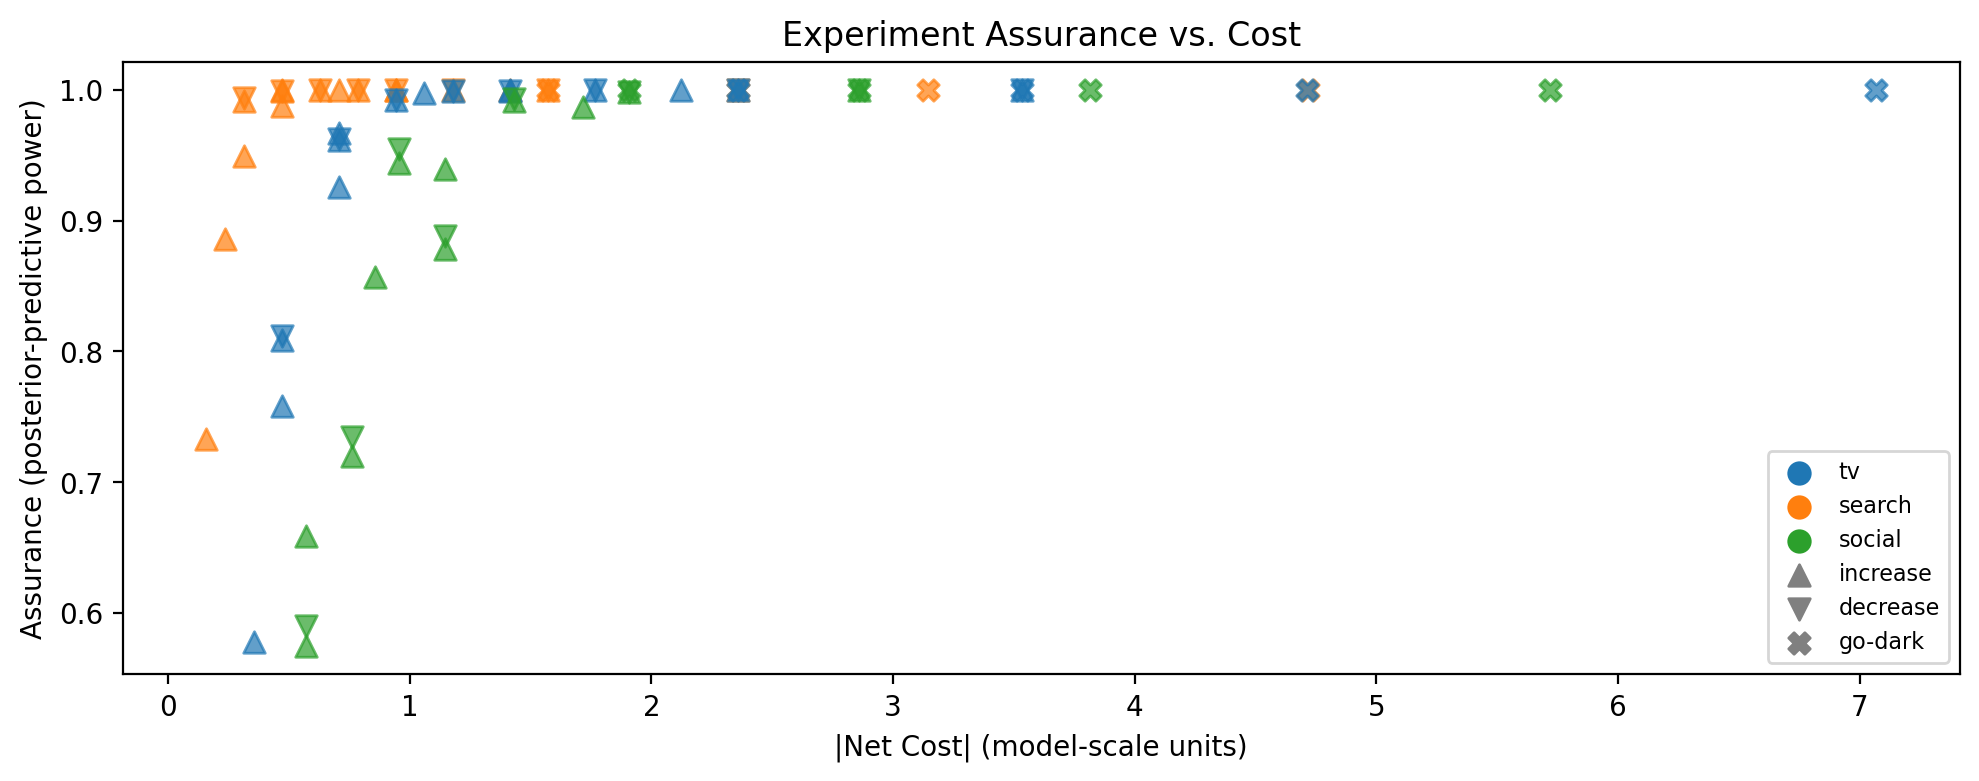

In [9]:
fig, ax = designer.plot_power_cost(
    recommendations, colors=CHANNEL_COLORS, figsize=(FIG_WIDTH, FIG_HEIGHT)
)
plt.show()

**Caption:** Bayesian assurance vs. absolute net cost for all candidate experiments passing the SNR filter. Marker color indicates channel; marker shape indicates spend direction (triangle-up = increase, triangle-down = decrease, X = go-dark).

#### Lift Distributions

Drilling into a single channel, we can inspect how the posterior lift distribution shifts with spend change magnitude and experiment duration. Distributions that clearly exclude zero indicate high-assurance experiments.

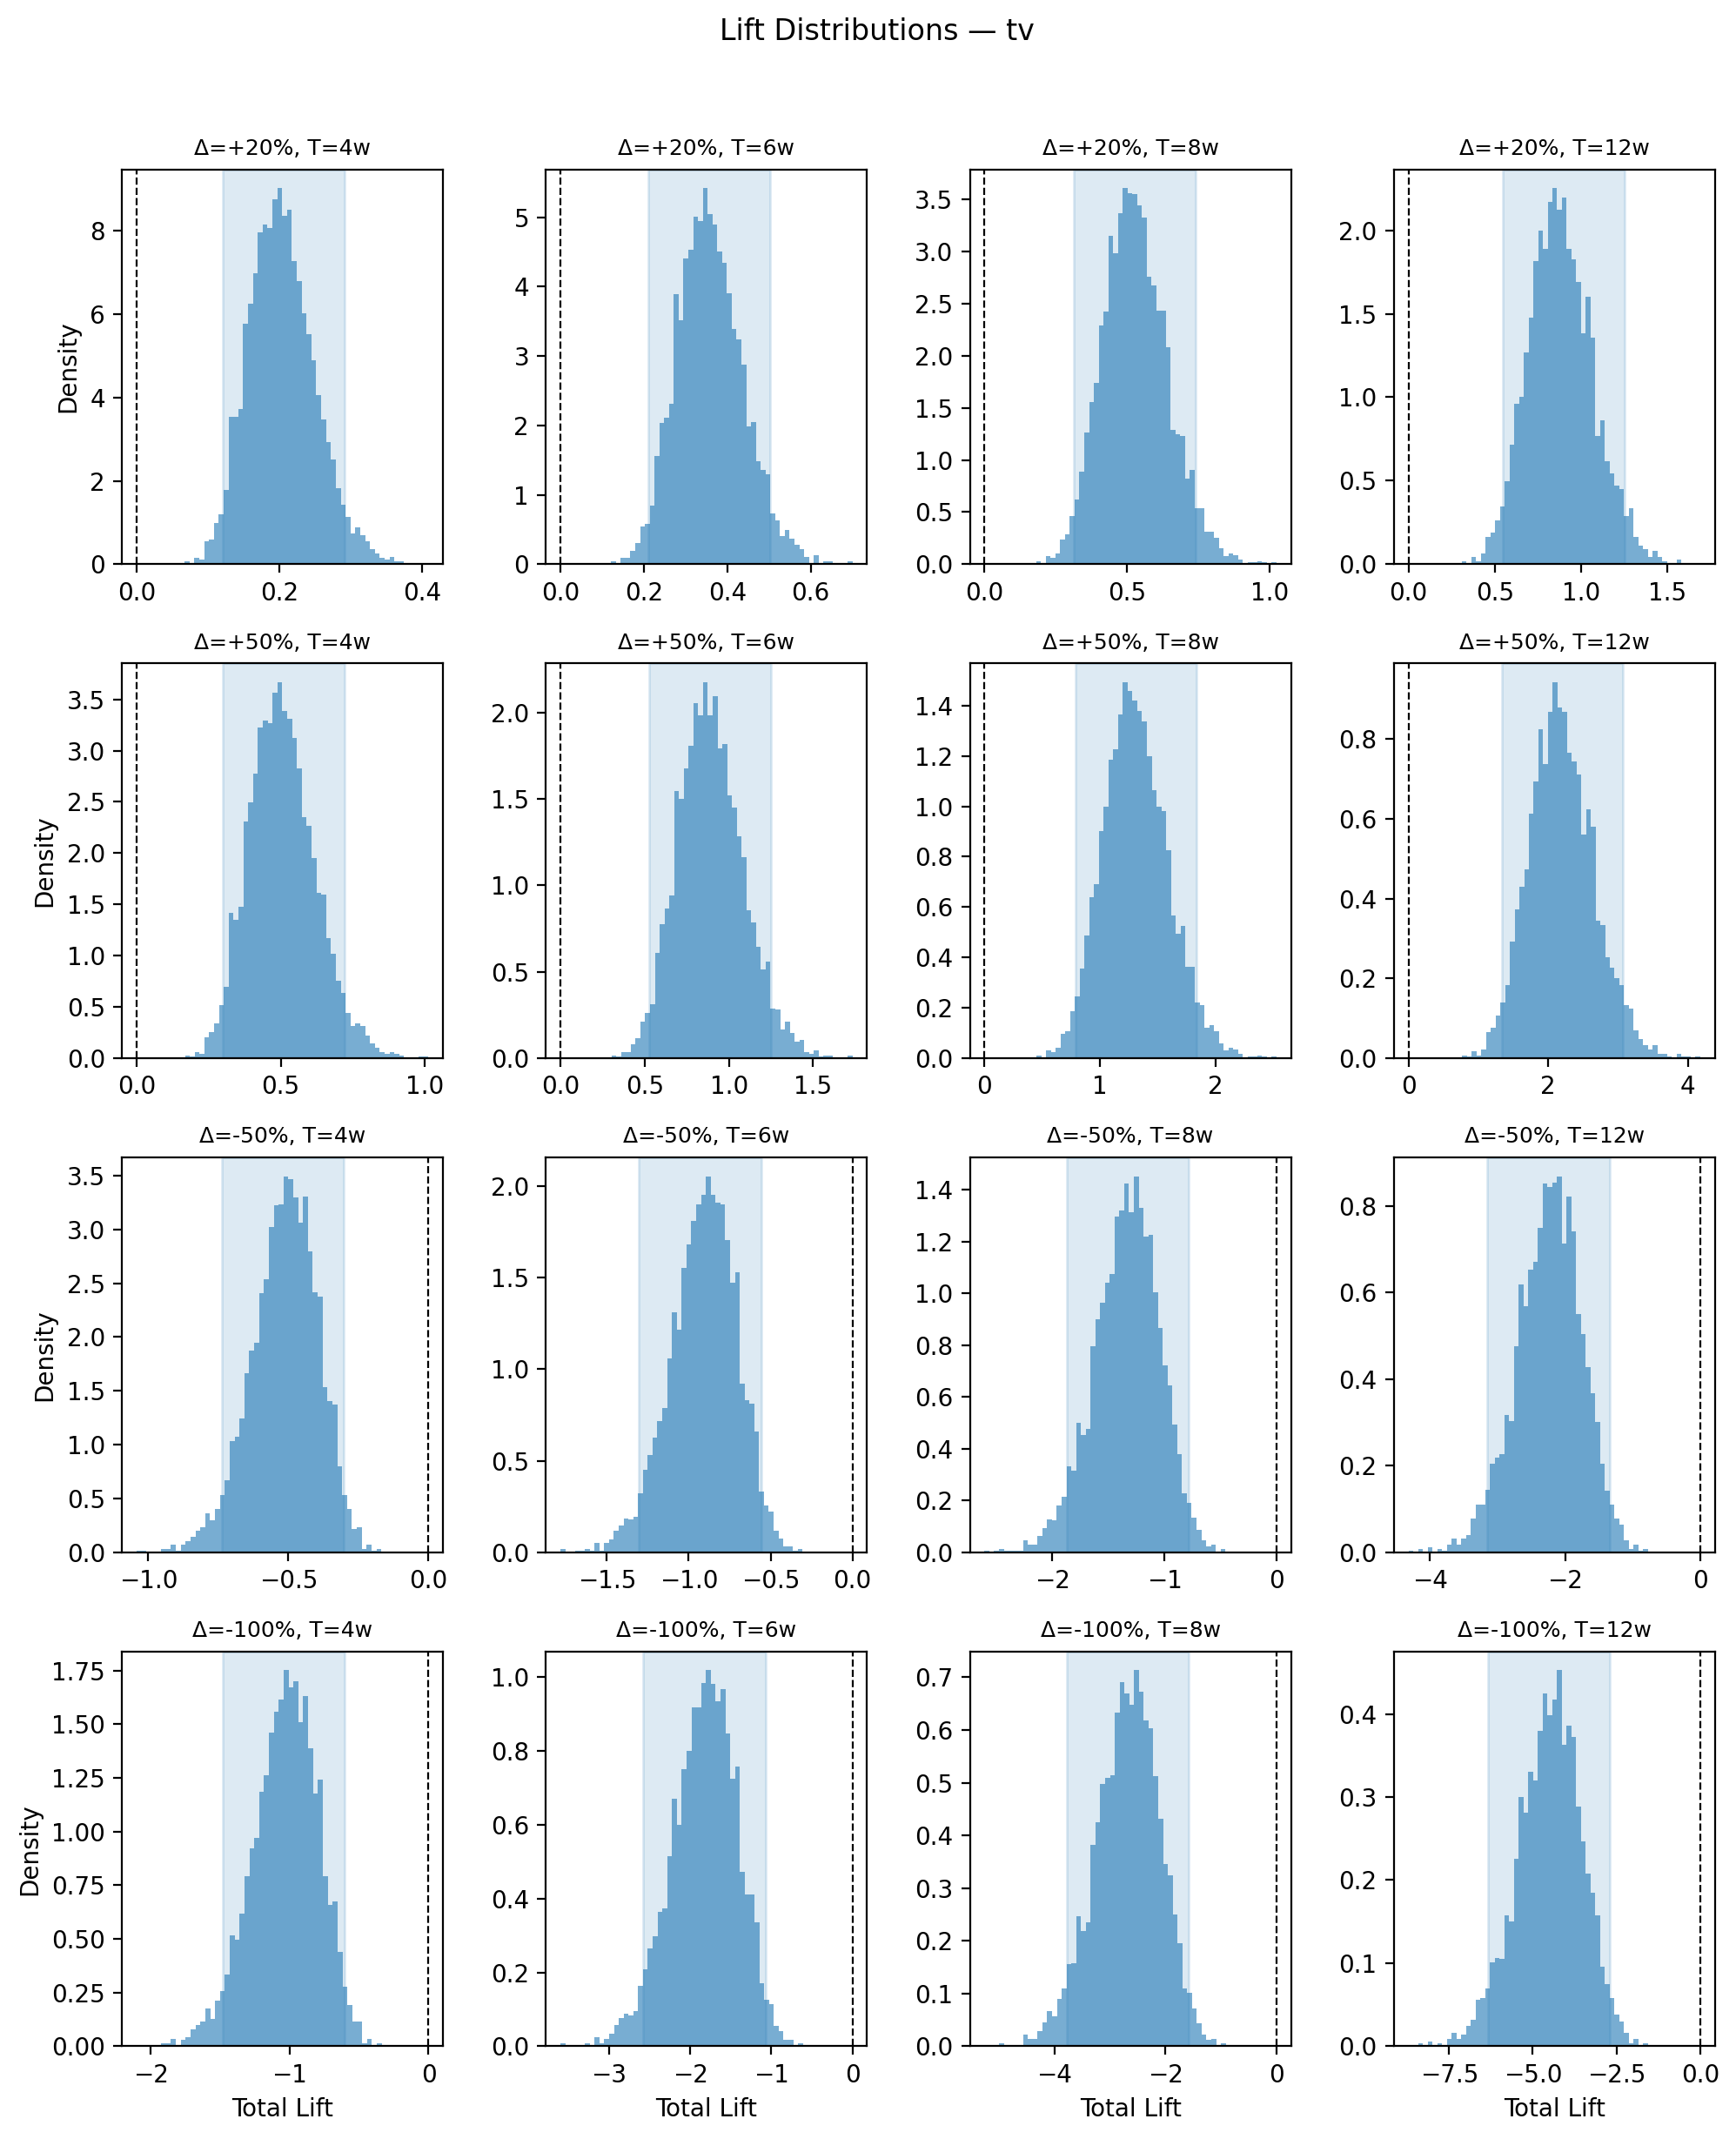

In [10]:
fig, axes = designer.plot_lift_distributions(
    "tv",
    spend_changes=[0.2, 0.5, -0.5, -1.0],
    durations=[4, 6, 8, 12],
    color=CHANNEL_COLORS["tv"],
    figsize=(FIG_WIDTH, FIG_HEIGHT * 3),
)
plt.show()

**Caption:** Posterior distribution of total predicted lift for the TV channel across spend changes (rows) and experiment durations (columns). Shaded region is the 94% HDI; vertical dashed line marks zero lift.

#### Adstock Ramp-up

This plot visualises the adstock ramp fraction discussed in [Adstock-Aware Lift Prediction](#adstock-aware-lift-prediction). Channels with slow decay (high $\alpha$) need longer experiments to capture the full steady-state effect.

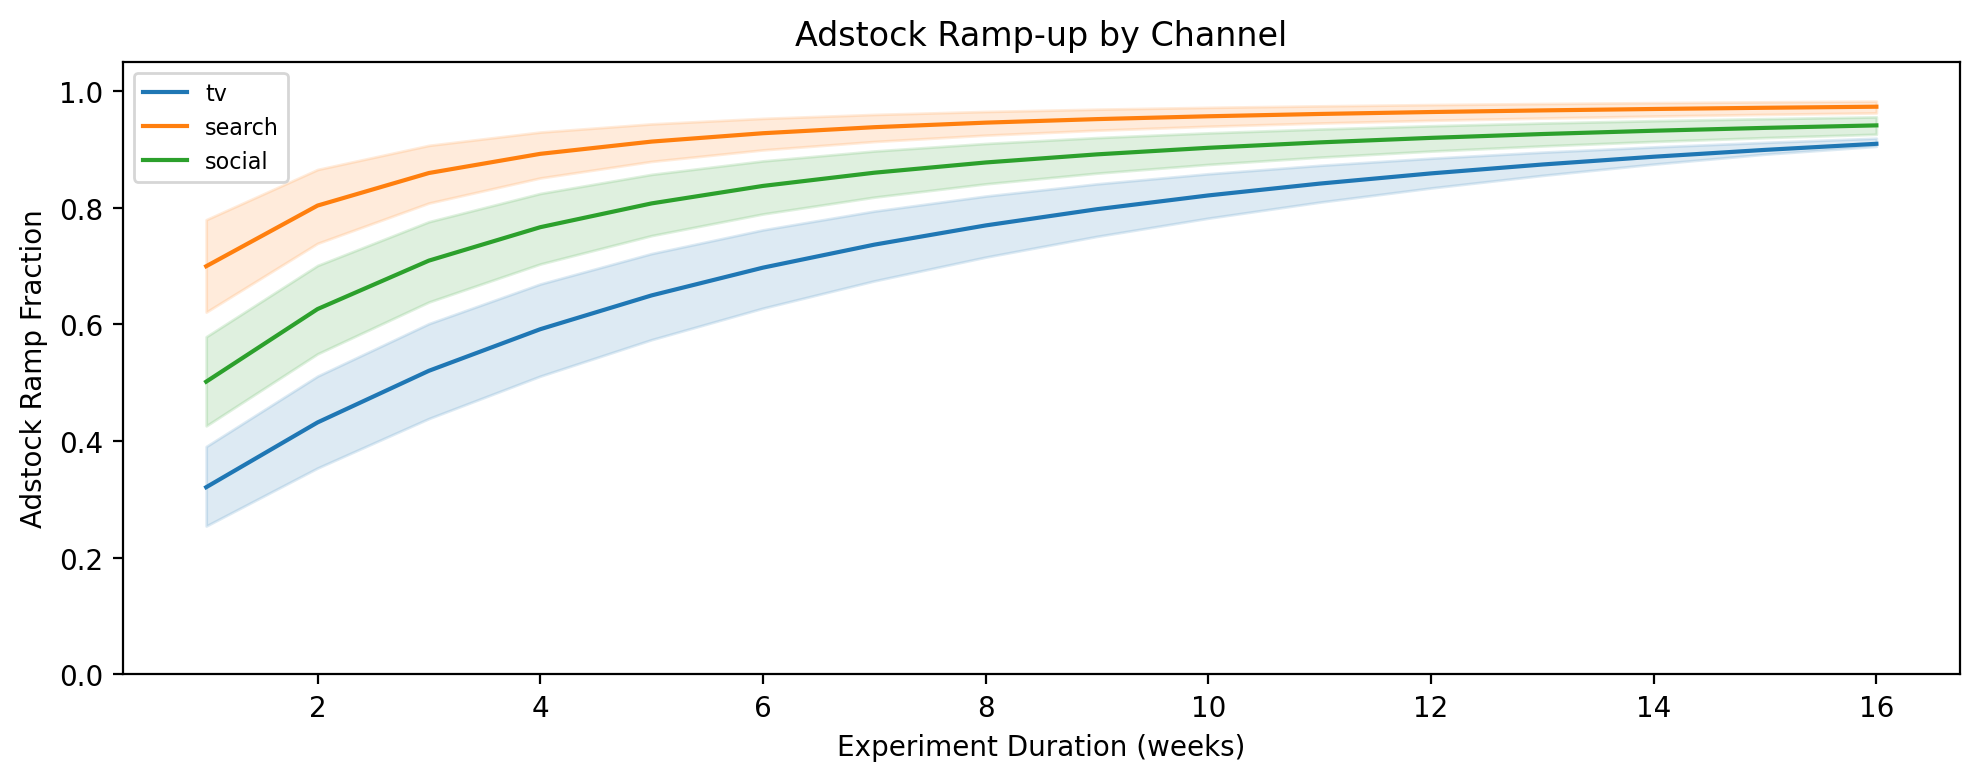

In [11]:
fig, ax = designer.plot_adstock_ramp(
    max_weeks=16, colors=CHANNEL_COLORS, figsize=(FIG_WIDTH, FIG_HEIGHT)
)
plt.show()

**Caption:** Adstock ramp fraction vs. experiment duration for each channel. Shaded band is the 89% posterior interval. Channels with higher adstock α approach steady state more slowly, requiring longer experiments to capture the full effect.

## Using with a Fitted MMM

In practice, you'd create the designer directly from a fitted `MMM`:

```python
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.experiment_design import ExperimentDesigner

mmm = MMM(
    date_column="date",
    channel_columns=["tv", "search", "social"],
    target_column="revenue",
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
)
mmm.fit(X, y)

designer = ExperimentDesigner(mmm)
recommendations = designer.recommend()
```

The designer extracts everything it needs from the fitted model: posterior samples, current spend levels, residual noise, and spend correlations.